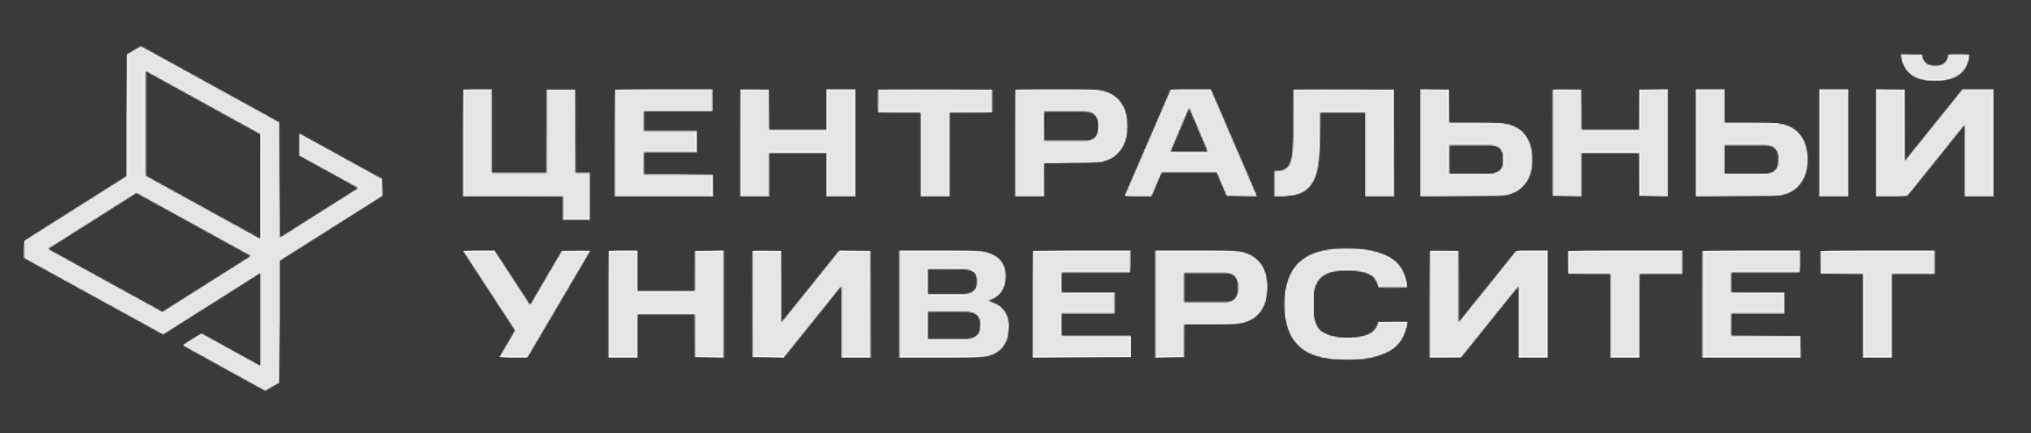


# Курс по Глубокому обучению

## Домашнее задание 2. Оптимизация и цикл обучения в PyTorch (10 баллов)

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличие работоспособного кода в ноутбуке, если не сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами "Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл


**ФИО:**

**Группа:**

## О задании

В этом домашнем задании вы:
1. реализуете вычислительный граф двумя способами (явные тензоры и `torch.nn`);
2. минимизируете квадратичную функцию с помощью `Adam`;
3. соберёте пайплайн обучения: `Dataset`, `collate_fn`, кастомные активации и цикл эпохи;
4. обучите сеть на табличном датасете MiniBooNE и добьётесь accuracy > 0.9 на тесте.

Каждая задача имеет «стоимость» в баллах. Рекомендуем решать задания по порядку.

<font color='OrangeRed'>**Обратите внимание!**</font> Для части экспериментов вам, вероятно, понадобится возможность работы с GPU. Мы предлагаем выполнять задание в Google Colab. При желании и наличии GPU на домашнем компьютере можно работать локально.

Если работаете в Colab, выберите GPU: **Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU** (или другой доступный GPU).

<font color='OrangeRed'>**Обратите внимание!**</font> Убедитесь, что при работе в Google Colab мы выбрали среду выполнения T4. Включить ее можно в менюшке, изображенной на картинках ниже:


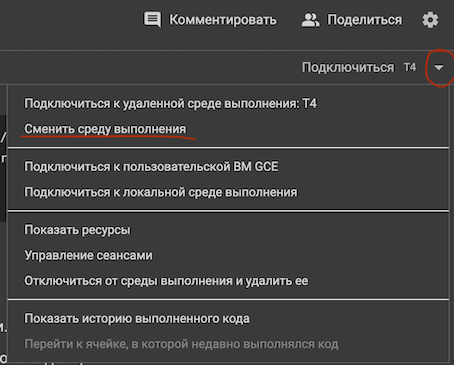


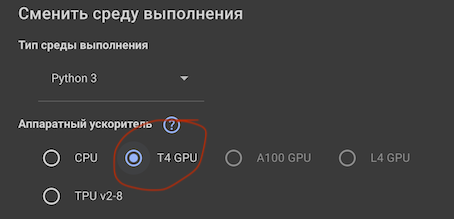


# Часть 1. Оптимизация и вычислительный граф

## <font color='DarkOrange'> **Задание 1 [3 балла]** </font>


На картинке ниже изображен граф вычислений. Ваша задача – написать код, моделирующий граф двумя способами: с помощью явных операций над тензорами и с помощью слоев из `torch.nn`.

Операция $\otimes$ – поэлементное умножение.

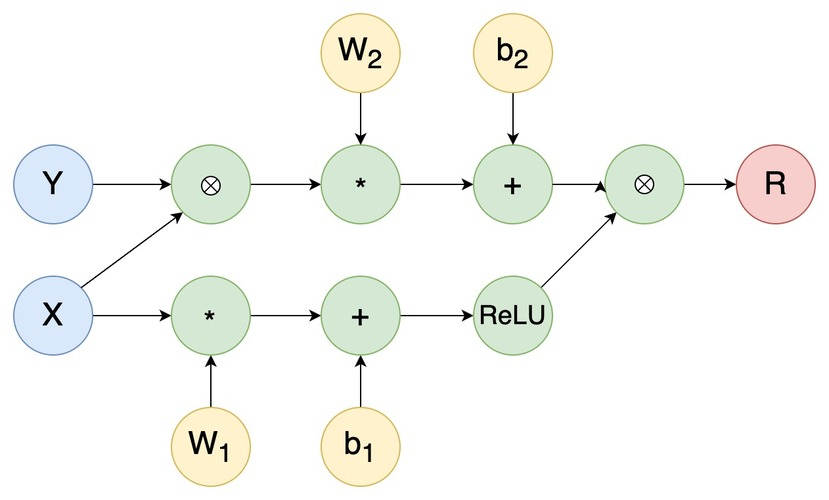

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


X = torch.rand((100, 32))
Y = torch.rand((100, 32))
W1 = torch.rand((64, 32))
W2 = torch.rand((64, 32))
b1 = torch.rand(64)
b2 = torch.rand(64)


<font color='DarkOrange'>**Задание [1.5 балла]:**</font>

Опишем граф в виде функции:

In [ ]:
def model(X, Y, W1, b1, W2, b2):
    R = None  # YOUR CODE HERE
    return R


<font color='DarkOrange'>**Задание [1.5 балла]:**</font>

Опишем граф в виде блоков из `torch.nn`, собранных в одну нейросеть.

Замечание: для копирования содержимого тензоров в параметры слоёв рекомендуется использовать схему:
```
with torch.no_grad():
    self.linear.weight.copy_(W)
    self.linear.bias.copy_(b)
```

In [ ]:
class Network(nn.Module):
    def __init__(self, W1, b1, W2, b2):
        super().__init__()

        self.linear1 = None  # YOUR CODE HERE
        self.linear2 = None  # YOUR CODE HERE
        self.relu = None  # YOUR CODE HERE

        pass  # YOUR CODE HERE

    def forward(self, X, Y):
        R = None  # YOUR CODE HERE
        return R


Проверим идентичность вычислений:

In [ ]:
network = Network(W1, b1, W2, b2)
value1 = model(X, Y, W1, b1, W2, b2)
value2 = network(X, Y)

assert torch.allclose(value1, value2), 'Реализации выдают неодинаковый результат'
print('Отлично!')


## <font color='DarkOrange'> **Задание 2 [2 балла]** </font>

Обучая нейронные сети, мы настраиваем внутренние веса таким образом, чтобы функционал качества был минимальным (минимизируем функцию потерь). Фактически мы находим минимум для некоторой сложной функции, устройство которой мы даже не всегда понимаем. Промоделируем этот процесс.

Пусть у нас есть функция:

$f(X) = ||Xa - b||^2 + ||Xb - a||^2$,

где $X \in \mathbb{R}^{n \times n}$ – переменная, по которой будет проводится оптимизация. $a, b \in \mathbb{R}^{n}$ – фиксированные вектора, а ||.|| – есть евклидова норма вектора (длина вектора).

Необходимо, используя оптимизатор `torch.Adam`, численно найти минимум функции и $X^*$, на котором этот минимум достигается.

Для начала все вычисления будем делать на **CPU**.

In [ ]:
from torch import optim


n = 2000
a = torch.normal(mean=0, std=1, size=(n,), requires_grad=False, device='cpu')
b = torch.normal(mean=0, std=1, size=(n,), requires_grad=False, device='cpu')


<font color='DarkOrange'>**Задание [1 балл]:**</font>

Опишите функцию $f(X)$:

In [ ]:
def f(X):
    return None  # YOUR CODE HERE

<font color='DarkOrange'>**Задание [1 балл]:**</font>

С помощью `optim.Adam` итеративно будем находить оптимальное значение $X$, на котором достигается минимум функции $f(X)$. Значения функции записываем в `f_value`, чтобы убедиться, что функция убывает.

Дополнение: большая часть циклов обучения нейронных сетей устроена схожим образом:
- `optimizer.zero_grad()` – отчищаем градиенты с предыдущих итераций;
- `y = f(X)` –  высчитываем значение функции (нейросети);
- `y.backward()` – вычисляем градиенты. Градиенты будут вычислены для всех переменных, у которых указана опция `requires_grad=True`. В нашем случае в формировании значения `y` участвуют `X`, `a` и `b`, но просчет градиентов определен только для `X` (к слову, `X` и записан как параметр оптимизации в `optim.Adam`);
- `optimizer.step()` – сделать один шаг оптимизатора в сторону поиска оптимального значения для `X`.

При обучении нейросетей вместо `X` будет набор весов сети `W`, а `f(X)` будет нейросетью `Network(W)`.

In [ ]:
%%time

X = torch.normal(mean=0.0, std=1.0, size=(n, n), requires_grad=True, device='cpu')  # YOUR CODE HERE
optimizer = optim.Adam([X], lr=1e-2)  # YOUR CODE HERE
f_value = []
for i in range(1000):
    optimizer.zero_grad()

    y = None  # YOUR CODE HERE
    f_value.append(None)  # YOUR CODE HERE
    y.backward()
    optimizer.step()


Посмотрим на график функции `y=f(X)`:

In [ ]:
import matplotlib.pyplot as plt

plt.plot(f_value)
plt.yscale('log')
plt.show()


In [ ]:
assert len(f_value) > 1, 'f_value пуст — сначала выполните цикл оптимизации'
assert f_value[-1] < f_value[0], 'Ожидалось убывание f(X) к концу оптимизации (подберите lr / число итераций)'
print('Отлично!')


Ответьте на вопросы:

* Убывает ли он?
* Если однозначного ответа на предыдущий пункт нет, то как вы думаете, почему такое поведение может наблюдаться?

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

<font color='DarkOrange'>**Задание (опционально):**</font>

При наличии GPU повторите эксперимент на `cuda` (замените устройство у `X`, `a` и `b`). Сравните время выполнения с `%%time`. Если GPU недоступен, пропустите пункт и кратко укажите это в выводах.

In [ ]:
%%time  # YOUR CODE HERE

Также проверьте график функции y=f(X):

In [ ]:
plt.plot(f_value)
plt.yscale('log')
plt.show()


<font color='MediumOrchid'>**Ваши выводы тут:**</font>


---

# Часть 2. Цикл обучения (MiniBooNE)

Ячейка ниже необходима, если на вашем компьютере (или в colab) не установлена библиотека `datasets`. В таком случае уберите комментирование и выполните ее. Обратите внимание, что ячейка попросит подтвердить первичное удаление библиотеки `pyarrow`.

In [ ]:
from IPython.display import clear_output

In [ ]:
# При необходимости (если datasets не ставится) раскомментируйте:
# !pip uninstall -y pyarrow
# !pip install pyarrow==15.0.2
# !pip install datasets
# clear_output()

try:
    import datasets
    print('datasets уже установлен')
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'datasets'])
    clear_output()
    print('datasets установлен')


In [ ]:
import numpy as np
import torch

from matplotlib import pyplot as plt

from torch import nn
from torch.optim import Optimizer, Adam
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm import tqdm


Для начала загрузим необходимый датасет. Данные взяты из физического эксперимента MiniBooNE (Fermilab). Детектор — бак с минеральным маслом, окружённый фотоумножителями, которые регистрируют черенковский свет от пролетающих частиц. Задача бинарной классификации: по 50 признакам, описывающим событие в детекторе, отличить сигнальные события электронных нейтрино от фоновых событий мюонных нейтрино. Датасет исторически любопытен: в исходной статье нейронные сети проиграли на нём бустингу над деревьями — посмотрим, что выжмет наш MLP.

B. Roe et al., "Boosted Decision Trees, an Alternative to Artificial Neural Networks", arXiv:physics/0408124, Nucl. Instrum. Meth. A543, 577 (2005).


In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("inria-soda/tabular-benchmark", data_files="clf_num/MiniBooNE.csv")
df = pd.DataFrame(dataset['train'])
df.head(2)


Набор данных содержит 50 признаков и таргет, который лежит в колонке `signal`. Разобьем его на train и test.

<font color='OrangeRed'>**Примечание**</font> не меняйте `random_state`!

In [ ]:
df_train, df_test = train_test_split(df, random_state=0)


## <font color='DarkOrange'> **Задание 3 [1 балл]** </font>


Вашим первым заданием будет реализация собственного класса на основе модуля `Dataset` из библиотеки `torch`. Реализуйте запись матрицы признаков в атрибут `_items` и лейблов в `_labels`. Также реализуйте метод `__len__`, возвращающий длину вашего датасета и метод `__getitem__`, возвращающий пару "элемент", "таргет" по индексу. Приведите колонку с таргетами к типу `integer`.

In [ ]:
import os

class MyCustomDataset(Dataset):
    def __init__(self, dataset, target_name):
        dataset = dataset.reset_index(drop=True)
        self._items = None  # YOUR CODE HERE
        self._labels = None  # YOUR CODE HERE
    def __len__(self,):
        return 0  # YOUR CODE HERE
    def __getitem__(self, idx):
        item = None  # YOUR CODE HERE
        label = None  # YOUR CODE HERE
        return item, label


При помощи вашего класса создайте датасеты для обучающей и тестовой выборки.

In [ ]:
test_dataset = None  # YOUR CODE HERE
train_dataset = None  # YOUR CODE HERE

Можете проверить реализацию вашего класса при помощи тестов.

In [ ]:
assert len(train_dataset) == 54748
assert len(train_dataset[0]) == 2
assert len(train_dataset[0][0]) == 50
assert np.issubdtype(type(train_dataset[0][1]), np.integer)
print('Отлично!')


## <font color='DarkOrange'> **Задание 4 [1 балл]** </font>

Теперь реализуем функцию, которая позволяет собирать объекты датасета в единый батч и представлять их в формате, необходимом `Dataloader`. Эта функция принимает на вход батч, состоящий из пар "признаки", "таргет", и возвращает два тензора: тензор признаков и тензор таргетов.

In [ ]:
def collate_fn(batch):
    items = None  # YOUR CODE HERE
    labels = None  # YOUR CODE HERE
    return items, labels


Воспользуемся вашей функцией для создания обучающего и тестового загрузчиков данных. Обратите внимание, что для `train` мы перемешиваем данные, а для `test` нет.

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=16, num_workers=0,
                              shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=16, num_workers=0,
                             shuffle=False, collate_fn=collate_fn)


Можете проверить реализацию:

In [ ]:
batch = next(iter(test_dataloader))
assert len(batch) == 2
assert batch[0].shape == torch.Size([16, 50])
assert batch[1].shape == torch.Size([16])
print('Отлично!')


## <font color='DarkOrange'> **Задание 5 [1 балл]** </font>

Теперь давайте реализуем две функции активации, которые могут помочь в ваших экспериментах. Первой будет ReLU:

$$ ReLU(x)=(x)^+ = \max(0, x) $$

In [ ]:
class CustomReLU(nn.Module):
    def forward(self, x):
        return x  # YOUR CODE HERE

Вторая функция - чуть более концептуальная `GELU`.

$$ GELU(x) = x \cdot \Phi(x), $$

где $ \Phi(x) $ - is the кумулятивная функция Гауссова распределения.

<font color='LightSteelBlue'>**Подсказка**</font> возможно вам потребуется `torch.distributions.normal` и ее встроенные методы.

In [ ]:
class CustomGELU(nn.Module):
    def forward(self, x):
        return x  # YOUR CODE HERE

Проверим, что все корректно работает:

In [ ]:
from numpy.testing import assert_allclose

my_relu = CustomReLU()
my_gelu = CustomGELU()

x = torch.tensor([-5.0, 0.0, 5.0])
assert torch.allclose(my_relu(x), F.relu(x))
assert_allclose(my_gelu(x), torch.tensor([-1.4901e-06, 0.0, 5.0]), rtol=1e-4, atol=0)
print('Отлично!')


## <font color='DarkOrange'> **Задание 6 [2 балла]** </font>

Наконец переходим к последнему и главному блоку: реализации цикла обучения. Для начала реализуйте метрику качества, по которой мы будем замерять успешность вашей модели. Помните, что ответы вашей модели приходят в виде вероятностей принадлежности к двум классам.

In [ ]:
# accuracy metric for our classification
def accuracy(model_labels, labels):
  '''
      model_labels: matrix of size NxK, where N - number of objects,
                    K - number of classes. Each row of matrix contains
                    probability of class j membership, where j - number of column
  '''
  return 0  # YOUR CODE HERE

In [ ]:
print('Отлично!')


Пустой контекст нужен нам, чтобы в рамках одной функции можно было обрабатывать как эпохи на обучении, так и эпохи на тестировании.

In [ ]:
class EmptyContext:
    def __enter__(self):
        pass

    def __exit__(self, *args):
        pass

Заполните комментарии ниже, руководствуясь подсказками.

In [ ]:
def perform_epoch(model, loader, criterion,
                optimizer=None, device=None):
    is_train = optimizer is not None
    model = model.to(device)

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    total_acc = 0
    total_n = 0
    with torch.no_grad() if not is_train else EmptyContext():
        for batch_data, batch_labels in loader:
            batch_data = None  # YOUR CODE HERE
            batch_labels = None  # YOUR CODE HERE
            model_labels = None  # YOUR CODE HERE
            new_loss = None  # YOUR CODE HERE
            if is_train:
                optimizer.zero_grad()  # YOUR CODE HERE
                new_loss.backward()  # YOUR CODE HERE
                optimizer.step()  # YOUR CODE HERE
            one_batch_loss = float(criterion(model_labels, batch_labels))
            one_batch_acc = accuracy(model_labels, batch_labels)

            total_loss += one_batch_loss
            total_acc += one_batch_acc
            total_n += 1
    return (total_loss / total_n, total_acc / total_n)


Создайте свою нейронную сеть. Это можно сделать как при помощи класса, так и при помощи контейнеров, которые мы разбирали в прошлых домашних заданиях / материалах курса.

Самостоятельно подберите оптимизатор и его гиперпараметры, а также количество эпох и архитектуру модели.

<font color='OrangeRed'>**Внимание!**</font> Добейтесь значения `accuracy` на тесте выше **0.9** - это необходимо для получения полного балла за данный блок задания.

In [ ]:
class Network(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()

        self.linear1 = None  # YOUR CODE HERE
        self.relu = None  # YOUR CODE HERE
        # архитектура может быть какая угодно

    def forward(self, x):
        return x  # YOUR CODE HERE
        # обратите внимание: после последнего линейного слоя не должно быть функций активации
        return x


In [ ]:
model = Network(50, 25, 2)
optimizer = None  # YOUR CODE HERE
epochs_num = None  # YOUR CODE HERE

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()

for epoch in tqdm(range(epochs_num)):
    loss, acc = perform_epoch(model, train_dataloader, criterion,
                                optimizer=optimizer, device=device)
    print(f"Epoch - {epoch} : loss {loss}, accuracy {acc}")
    print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")


In [ ]:
loss, acc = perform_epoch(model, test_dataloader, criterion, device=device)
print(f"Test result: loss {loss}, accuracy {acc}")


In [ ]:
assert acc > 0.905, 'Нужно accuracy > 0.905'
print('Отлично!')


## Готово

Убедитесь, что:
* все assert-ячейки выполняются без ошибок;
* на тесте MiniBooNE получено `accuracy > 0.9`;
* заполнены текстовые выводы там, где они запрошены;
* указаны ФИО и группа.